


Project-01:  ***Mini Transformer***
*   Date: Dec 20, 2025
*   Author: [**Md Shafaque**](https://www.linkedin.com/in/md-shafaque-37973b280/?originalSubdomain=in)






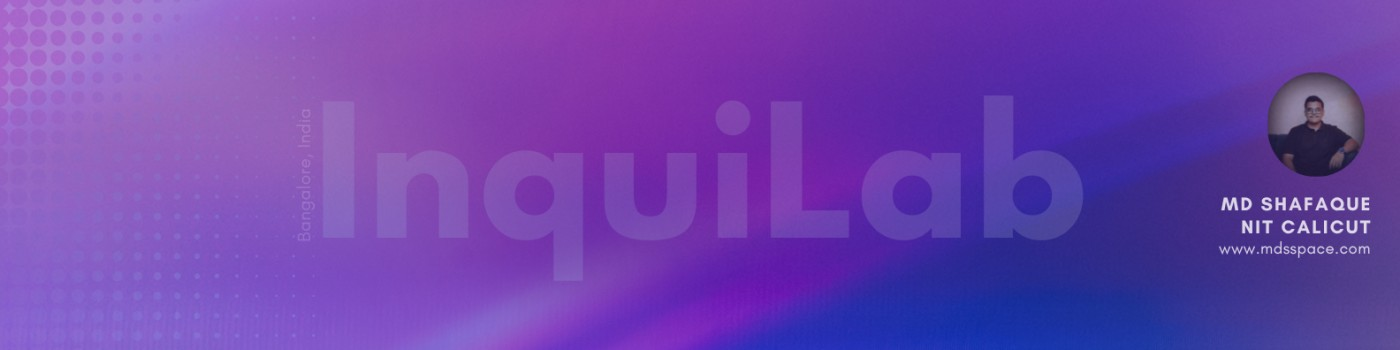

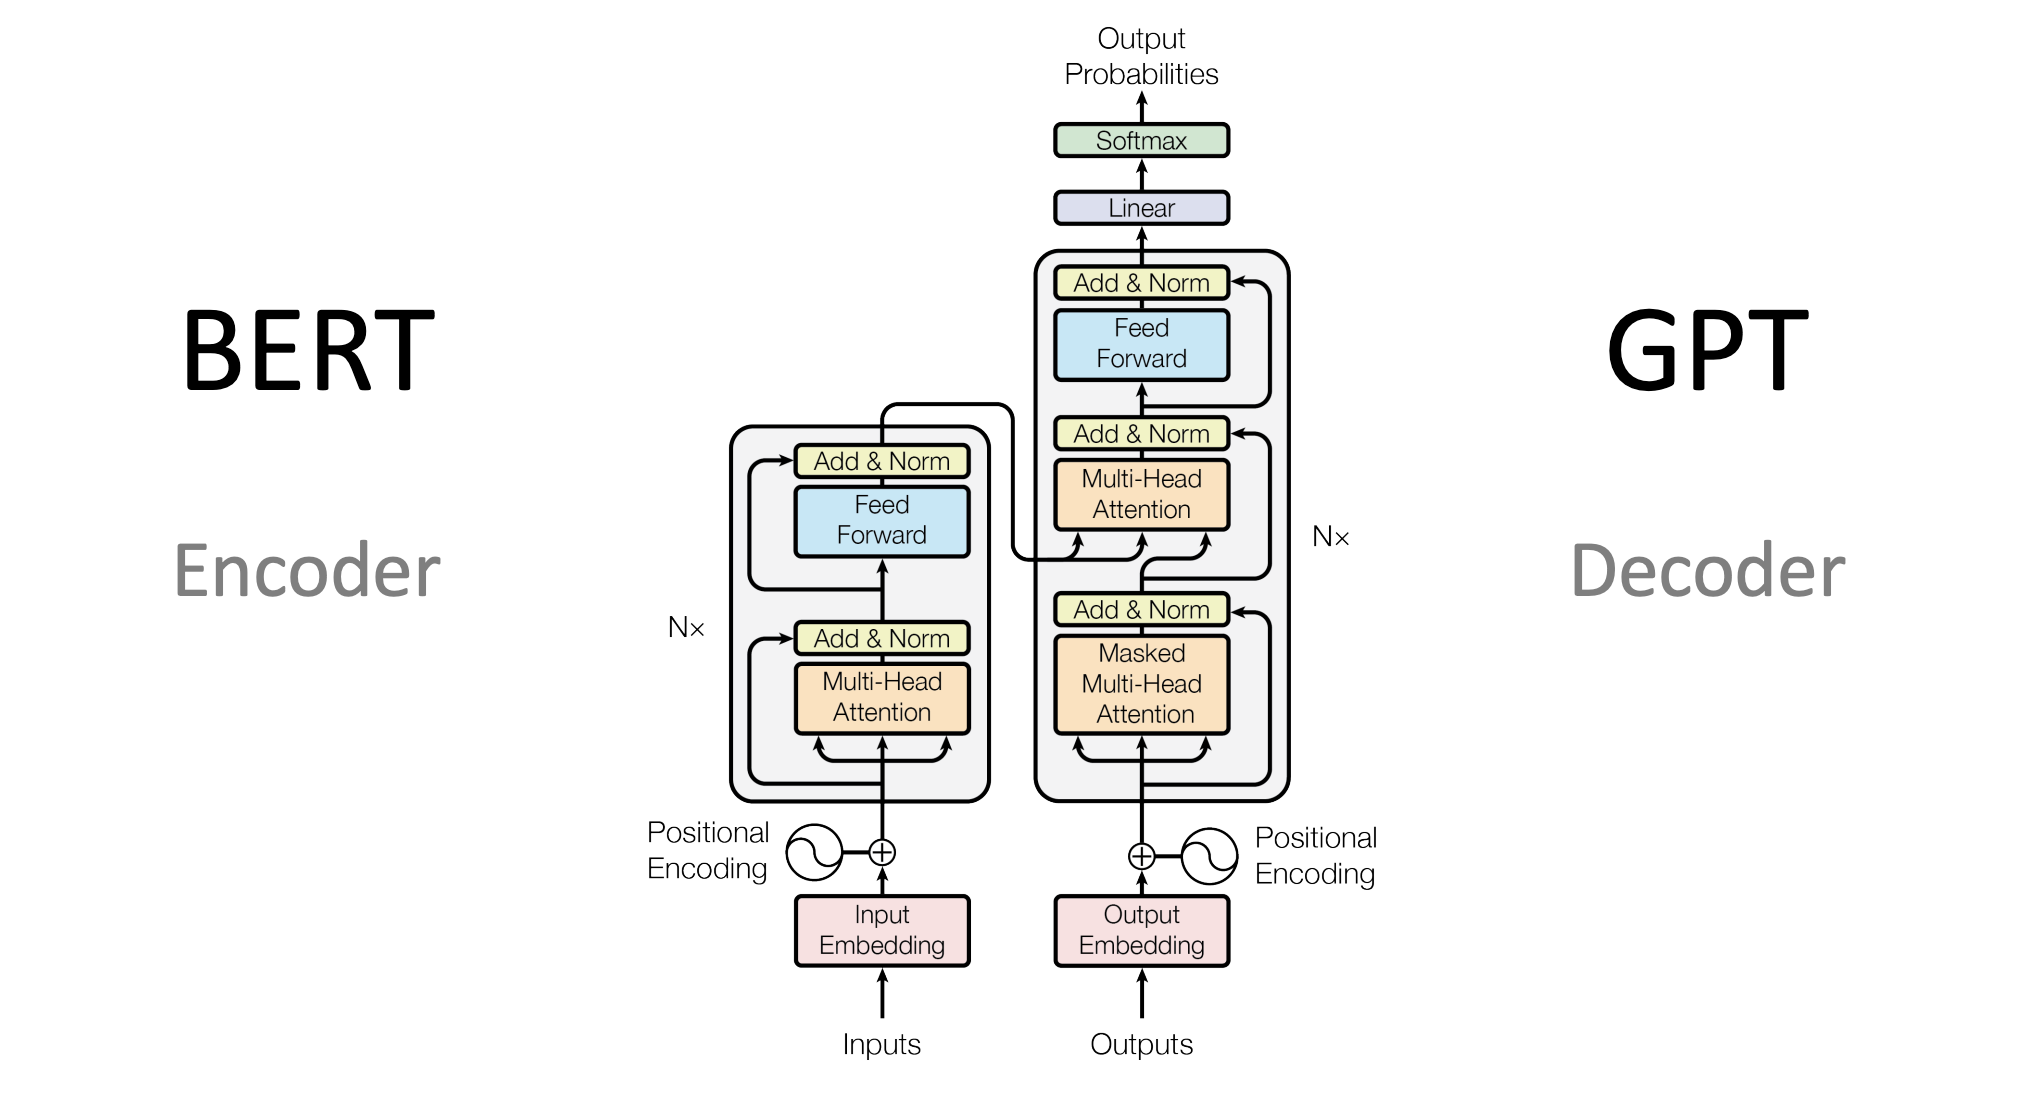

## **Importing Libraries**

In this notebook, PyTorch is used as the primary deep learning framework due to its
dynamic computation graph, ease of debugging, and strong support for research-oriented
model development.

The following functional roles are required:
- **Tensor operations** for numerical computation
- **Neural network modules** for layers like Linear, Embedding, LayerNorm
- **Autograd** for automatic differentiation
- **Optimization utilities** for gradient-based learning
- **Mathematical utilities** for scaling and normalization

This setup mirrors real-world Transformer research pipelines.


In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


# **Tokenizer (Word-level, simple & transparent)**

Tokenization is the process of converting raw text into numerical representations
that a neural network can process.

In this notebook, a **word-level tokenizer** is used for clarity and educational purposes.

### Process:
1. Split text into words based on whitespace
2. Assign a unique integer ID to each word
3. Introduce special tokens:
   - `<PAD>` : padding token
   - `<UNK>` : unknown word token
   - `<EOS>` : end-of-sequence token

### Why word-level?
- Easy to understand
- Good for small datasets
- Transparent mapping between text and tokens

⚠ Limitation:
Word-level tokenizers do not generalize well to unseen words.
Modern LLMs use **subword tokenization (BPE / WordPiece)** to solve this.


In [50]:
class SimpleTokenizer:
    def __init__(self, texts):
        words = set()
        for t in texts:
            words.update(t.split())

        self.word2id = {
            "<PAD>": 0,
            "<UNK>": 1,
            "<EOS>": 2
        }

        for w in sorted(words):
            if w not in self.word2id:
                self.word2id[w] = len(self.word2id)

        self.id2word = {i: w for w, i in self.word2id.items()}

    def encode(self, text):
        return [self.word2id.get(w, 1) for w in text.split()] + [2]

    def decode(self, ids):
        words = []
        for i in ids:
            if i == 2:
                break
            if i > 2:
                words.append(self.id2word[i])
        return " ".join(words)

    @property
    def vocab_size(self):
        return len(self.word2id)


## **Multi-Head Self Attention**

Self-attention allows each token in a sequence to **attend to every other token**
and decide which ones are important for contextual understanding.

---

### Step 1: Query, Key, Value (QKV)

Given input embeddings $X \in \mathbb{R}^{T \times d}$:

$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
$$

where:
- $W_Q, W_K, W_V$ are learnable weight matrices
- $Q, K, V \in \mathbb{R}^{T \times d_k}$

---

### Step 2: Scaled Dot-Product Attention

$$
\mathrm{Attention}(Q, K, V)
=
\mathrm{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)
V
$$

- Dot product measures similarity between tokens  
- Scaling by $\sqrt{d_k}$ prevents large gradients  
- Softmax converts scores into probabilities  

---

### Step 3: Causal Masking (Autoregressive)

To prevent future-token leakage, a causal mask is applied:

$$
\mathrm{Mask}_{i,j} =
\begin{cases}
0 & \text{if } j > i \\
1 & \text{if } j \le i
\end{cases}
$$

This ensures token $i$ can only attend to tokens at positions
$1$ through $i$, enforcing **left-to-right generation**.

---

### Step 4: Multi-Head Attention

Instead of a single attention operation, multiple attention heads
are used in parallel:

$$
\mathrm{MultiHead}(X)
=
\mathrm{Concat}(\mathrm{head}_1, \mathrm{head}_2, \dots, \mathrm{head}_h)\, W_O
$$

Each attention head learns different types of relationships:
- **Syntactic** patterns  
- **Semantic** meaning  
- **Long-range** dependencies  


In [52]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        assert d_model % heads == 0

        self.h = heads
        self.dk = d_model // heads

        self.qkv = nn.Linear(d_model, d_model * 3)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, D = x.shape

        qkv = self.qkv(x).chunk(3, dim=-1)
        Q, K, V = [
            t.view(B, T, self.h, self.dk).transpose(1, 2)
            for t in qkv
        ]

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.dk)

        mask = torch.tril(torch.ones(T, T)).to(x.device)
        scores = scores.masked_fill(mask == 0, -1e9)

        attn = F.softmax(scores, dim=-1)
        out = attn @ V

        out = out.transpose(1, 2).contiguous().view(B, T, D)
        return self.out(out)


## **Transformer Block**

A Transformer block consists of two main sublayers:

---

### 1. Multi-Head Self Attention
This sublayer captures contextual relationships between tokens by allowing
each token to attend to other relevant tokens in the sequence.

---

### 2. Feed Forward Network (FFN)
The Feed Forward Network applies non-linear transformations independently
to each token.

$$
\mathrm{FFN}(x)
=
\max(0, xW_1 + b_1) W_2 + b_2
$$

---

### Residual Connections

Residual connections add the input of a sublayer back to its output:

$$
x = x + \mathrm{Sublayer}(x)
$$

Residual connections:
- Improve gradient flow
- Prevent vanishing gradients
- Enable training of deeper models

---

### Layer Normalization

Layer normalization stabilizes training by normalizing activations:

$$
\mathrm{LayerNorm}(x)
=
\frac{x - \mu}{\sigma}
$$

Layer normalization is applied **after the residual addition** to ensure
numerical stability during training.


In [53]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, heads, d_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, heads)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


## **Mini Transformer (Encoder-Only GPT-style)**

This model follows an **encoder-only Transformer architecture**, similar in spirit
to GPT-style language models.

---

### Key Characteristics
- Uses **self-attention only** (no cross-attention)
- **Causal masking** enforces autoregressive behavior
- Predicts the **next token** based on previous tokens

---

### Architecture Flow

Input Tokens  
→ Token Embeddings  
→ Positional Encoding  
→ Transformer Blocks (× N)  
→ Linear Projection  
→ Softmax over Vocabulary

---

### Use Cases

This architecture is sufficient for:
- Language modeling
- Next-token prediction
- Autoregressive text generation


In [54]:
class MiniTransformer(nn.Module):
    def __init__(self, vocab, d_model=128, heads=4, layers=2, max_len=50):
        super().__init__()

        self.embed = nn.Embedding(vocab, d_model)
        self.pos = PositionalEncoding(d_model, max_len)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, heads, d_model * 4)
            for _ in range(layers)
        ])

        self.lm_head = nn.Linear(d_model, vocab)

    def forward(self, x):
        x = self.embed(x)
        x = self.pos(x)

        for blk in self.blocks:
            x = blk(x)

        return self.lm_head(x)


## **Training with Teacher Forcing**

Teacher forcing is a training strategy where the model is provided with the **true
previous tokens** as input, instead of using its own predictions.

---

### Training Objective

Given a sequence:

$$
(x_1, x_2, \dots, x_T)
$$

the model learns to estimate the conditional probability:

$$
P(x_t \mid x_1, x_2, \dots, x_{t-1})
$$

This enables the model to learn next-token prediction efficiently.

---

### Loss Function (Cross Entropy)

The training objective is to minimize the cross-entropy loss:

$$
\mathcal{L}
=
- \sum y \log(\hat{y})
$$

Padding tokens are ignored during loss computation to prevent bias:
- Ensures learning focuses only on real tokens
- Avoids artificial loss minimization due to padding

---

### Key Difference Between Training and Inference

| Training | Inference |
|--------|-----------|
Parallel computation | Sequential computation |
Uses teacher tokens | Uses model predictions |
Faster | Slower |


In [55]:
def make_dataset(texts, tokenizer, max_len):
    X, Y = [], []

    for t in texts:
        ids = tokenizer.encode(t)

        for i in range(1, len(ids)):
            x = ids[:i]
            y = ids[1:i+1]

            x += [0] * (max_len - len(x))
            y += [0] * (max_len - len(y))

            X.append(x)
            Y.append(y)

    return torch.tensor(X), torch.tensor(Y)


In [56]:
texts = [
    "allah is merciful",
    "allah is kind",
    "allah loves patience",
    "patience is rewarded",
    "allah rewards patience"
]

tokenizer = SimpleTokenizer(texts)
max_len = 20

X, Y = make_dataset(texts, tokenizer, max_len)

model = MiniTransformer(tokenizer.vocab_size, max_len=max_len)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

pad_id = tokenizer.word2id["<PAD>"]

for epoch in range(300):
    model.train()
    logits = model(X)

    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        Y.view(-1),
        ignore_index=pad_id
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss {loss.item():.4f}")


Epoch 0 | Loss 2.6667
Epoch 50 | Loss 0.5115
Epoch 100 | Loss 0.5093
Epoch 150 | Loss 0.5089
Epoch 200 | Loss 0.5086
Epoch 250 | Loss 0.5085


## **Generation (Sampling, EOS-aware)**

During inference, the model generates text **autoregressively**, meaning each
new token is generated based on previously generated tokens.

---

### Autoregressive Generation Process

1. Start with an initial prompt  
2. Predict the probability distribution for the next token  
3. Sample a token from the distribution  
4. Append the token to the input sequence  
5. Repeat until the `<EOS>` token is produced or the maximum length is reached  

---

### Temperature Sampling

Temperature controls the randomness of the sampling process.

$$
P_i
=
\frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}
$$

where:
- $z_i$ is the logit for token $i$
- $T$ is the temperature parameter

- Low $T$ → more deterministic output  
- High $T$ → more diverse and creative output  

---

### Why Sampling?

Greedy decoding (always selecting the highest-probability token) often leads to:
- Repetition loops  
- Mode collapse  

Sampling introduces controlled randomness, improving diversity and
naturalness in generated text.


In [57]:
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new=20, temp=0.8):
    model.eval()

    tokens = tokenizer.encode(prompt)[:-1]

    for _ in range(max_new):
        x = torch.tensor(tokens).unsqueeze(0)
        logits = model(x)[0, -1] / temp

        logits[tokenizer.word2id["<PAD>"]] = -1e9
        probs = torch.softmax(logits, dim=0)

        next_id = torch.multinomial(probs, 1).item()
        if next_id == tokenizer.word2id["<EOS>"]:
            break

        tokens.append(next_id)

    return tokenizer.decode(tokens)



## **Test & Observations**

---

### Observations
- The model learns **local syntactic patterns** quickly
- Repetition occurs due to the **small and repetitive dataset**
- Generation quality is **bounded by data diversity**, not architecture

---

### Key Takeaway

The Transformer architecture and training pipeline are **correct and functional**.
Observed limitations arise primarily from:

- Limited dataset size
- Coarse (word-level) tokenization
- Restricted context length

Scaling the dataset, improving tokenization (e.g., subword methods),
and increasing context length can significantly enhance generation quality.


In [58]:
print(generate(model, tokenizer, "allah"))
print(generate(model, tokenizer, "patience"))
print(generate(model, tokenizer, "allah is"))


allah is kind
patience is rewarded
allah is kind
